# Ridge, Lasso and Elastic Net Logistic Regression
## Part A — Regularisation Comparison | Part B — Shrinkage Paths

### Data assumption
The data is preprocessed once in Section 2. This notebook then works with:
- `X_train` = 80% preprocessed features
- `X_test` = 20% preprocessed features
- `y_train`
- `y_test`

Because `compare_regularisation()` requires validation data, 20% of the existing `X_train` is separated as validation data. The original `X_test` remains untouched for final evaluation.

### Requested Titanic survival-prediction features
`Sex_male`, `Pclass`, `Age`, `SibSp`, `Fare`

If preprocessing has transformed these columns, the notebook uses the actual columns present in `X_train`.

## Part A — Compare Regularisation

### Objective
Compare Ridge (L2), Lasso (L1), and Elastic Net Logistic Regression for several values of `C`.

Required output:
`C, Lasso_val_acc, Ridge_val_acc, ElasticNet_val_acc, Lasso_nonzero, Ridge_nonzero`

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## 2. Load the Data and Create the Preprocessed Train/Test Split

In [2]:
# ------------------------------------------------------------
# Load the raw CSV and rebuild the preprocessed 80/20 train-test data.
# (The processed train/test CSV files are not stored on disk, so the
#  same preprocessing steps are applied here once, before modelling.)
# Steps: drop duplicates -> split -> median-impute numeric (+ missing
# indicators) -> mode-impute + one-hot encode nominal -> standard-scale.
# ------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DATA_PATH = r"C:\Users\dhruv\OneDrive\KLH Univeristy\4th semester (Trimester Format KLH)\25SC2107E Machine Learning\Placement Prediction System (OS-SEC-2(2026-27))\data\titanic.csv"

TARGET = "Survived"
DROP_COLS = ['PassengerId', 'Name', 'Ticket', 'Cabin']          # identifier / free-text columns
ORDINAL_MAPS = {}        # ordered categories -> integers

df = pd.read_csv(DATA_PATH)
df = df.drop_duplicates().reset_index(drop=True)

X = df.drop(columns=[TARGET] + DROP_COLS)
y = df[TARGET]

for col, mapping in ORDINAL_MAPS.items():
    if col in X.columns:
        X[col] = X[col].map(mapping)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
nominal_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# ----- numeric: median imputation (fit on train only) + missing indicators -----
num_imputer = SimpleImputer(strategy="median")
X_train_num = pd.DataFrame(num_imputer.fit_transform(X_train[numeric_cols]),
                           columns=numeric_cols, index=X_train.index)
X_test_num = pd.DataFrame(num_imputer.transform(X_test[numeric_cols]),
                          columns=numeric_cols, index=X_test.index)

for col in [c for c in numeric_cols if X_train[c].isna().any()]:
    X_train_num[col + "_missing"] = X_train[col].isna().astype(int)
    X_test_num[col + "_missing"] = X_test[col].isna().astype(int)

# ----- nominal: most-frequent imputation + one-hot encoding (drop first) -----
parts_train, parts_test = [X_train_num], [X_test_num]
if nominal_cols:
    nom_imputer = SimpleImputer(strategy="most_frequent")
    X_train_nom = pd.DataFrame(nom_imputer.fit_transform(X_train[nominal_cols]),
                               columns=nominal_cols, index=X_train.index)
    X_test_nom = pd.DataFrame(nom_imputer.transform(X_test[nominal_cols]),
                              columns=nominal_cols, index=X_test.index)

    encoder = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
    enc_train = encoder.fit_transform(X_train_nom)
    enc_names = encoder.get_feature_names_out(nominal_cols)
    parts_train.append(pd.DataFrame(enc_train, columns=enc_names, index=X_train.index))
    parts_test.append(pd.DataFrame(encoder.transform(X_test_nom), columns=enc_names, index=X_test.index))

X_train_processed = pd.concat(parts_train, axis=1)
X_test_processed = pd.concat(parts_test, axis=1)

# ----- scaling (fit on train only) -----
scaler = StandardScaler()
X_train_processed[numeric_cols] = scaler.fit_transform(X_train_processed[numeric_cols])
X_test_processed[numeric_cols] = scaler.transform(X_test_processed[numeric_cols])

print("Raw data shape      :", df.shape)
print("X_train_processed   :", X_train_processed.shape)
print("X_test_processed    :", X_test_processed.shape)

Raw data shape      : (891, 12)
X_train_processed   : (712, 9)
X_test_processed    : (179, 9)


In [3]:
feature_cols = ['Sex_male', 'Pclass', 'Age', 'SibSp', 'Fare']

X_train = X_train_processed[feature_cols]
X_test  = X_test_processed[feature_cols]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (712, 5)
X_test : (179, 5)
y_train: (712,)
y_test : (179,)


In [4]:
print("Missing values in X_train:", X_train.isna().sum().sum())
print("Missing values in X_test :", X_test.isna().sum().sum())

print("\ny_train distribution:")
print(y_train.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())

print("\nPreprocessed feature columns:")
print(list(X_train.columns))

Missing values in X_train: 0
Missing values in X_test : 0

y_train distribution:
Survived
0    439
1    273
Name: count, dtype: int64

y_test distribution:
Survived
0    110
1     69
Name: count, dtype: int64

Preprocessed feature columns:
['Sex_male', 'Pclass', 'Age', 'SibSp', 'Fare']


## 3. Create Validation Set from the Existing 80% Training Data

In [5]:
# Do NOT use X_test to create validation data.
# The original 20% test set remains untouched.

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Model-training portion:", X_train.shape)
print("Validation portion   :", X_val.shape)
print("Untouched test set   :", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

Model-training portion: (569, 5)
Validation portion   : (143, 5)
Untouched test set   : (179, 5)

y_train: (569,)
y_val  : (143,)
y_test : (179,)


### Final data usage

Existing 80% training data:
- 80% of it → model training = about 64% of original data
- 20% of it → validation = about 16% of original data

Existing 20% test data:
- remains untouched = 20% of original data

## 4. Define C Values

In [6]:
# C = 1 / lambda
# Smaller C -> stronger regularisation
# Larger C -> weaker regularisation

C_values = np.array([0.001, 0.01, 0.1, 1, 10, 100])

# Elastic Net mixing parameter
L1_RATIO = 0.5

print("C values:", C_values)
print("Elastic Net l1_ratio:", L1_RATIO)

C values: [1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
Elastic Net l1_ratio: 0.5


## 5. Implement `compare_regularisation()`

In [7]:
def compare_regularisation(    X_train, y_train,X_val,y_val, C_values, l1_ratio=0.5, zero_tol=1e-8):
    results = []

    for C in C_values:

        # Lasso: L1
        lasso = LogisticRegression(
            penalty="l1",
            C=C,
            solver="liblinear",
            max_iter=2000,
            random_state=42
        )
        lasso.fit(X_train, y_train)
        lasso_val_acc = accuracy_score(
            y_val, lasso.predict(X_val)
        )
        lasso_nonzero = int(
            np.sum(np.abs(lasso.coef_) > zero_tol)
        )

        # Ridge: L2
        ridge = LogisticRegression(
            penalty="l2",
            C=C,
            solver="lbfgs",
            max_iter=2000,
            random_state=42
        )
        ridge.fit(X_train, y_train)
        ridge_val_acc = accuracy_score(
            y_val, ridge.predict(X_val)
        )
        ridge_nonzero = int(
            np.sum(np.abs(ridge.coef_) > zero_tol)
        )

        # Elastic Net: L1 + L2
        elastic = LogisticRegression(
            penalty="elasticnet",
            C=C,
            l1_ratio=l1_ratio,
            solver="saga",
            max_iter=3000,
            random_state=42
        )
        elastic.fit(X_train, y_train)
        elastic_val_acc = accuracy_score(
            y_val, elastic.predict(X_val)
        )

        results.append({
            "C": C,
            "Lasso_val_acc": lasso_val_acc,
            "Ridge_val_acc": ridge_val_acc,
            "ElasticNet_val_acc": elastic_val_acc,
            "Lasso_nonzero": lasso_nonzero,
            "Ridge_nonzero": ridge_nonzero
        })

    return pd.DataFrame(results)

## 6. Generate the Required Comparison DataFrame

In [8]:
results_df = compare_regularisation(
    X_train,
    y_train,
    X_val,
    y_val,
    C_values,
    l1_ratio=L1_RATIO
)

display(results_df)

C:\Users\dhruv\OneDrive\KLH Univeristy\4th semester (Trimester Format KLH)\25SC2107E Machine Learning\Placement Prediction System (OS-SEC-2(2026-27))\.MLvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\dhruv\OneDrive\KLH Univeristy\4th semester (Trimester Format KLH)\25SC2107E Machine Learning\Placement Prediction System (OS-SEC-2(2026-27))\.MLvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\dhruv\OneDrive\KLH Univeristy\4th semester

,C,Lasso_val_acc,Ridge_val_acc,ElasticNet_val_acc,Lasso_nonzero,Ridge_nonzero
0,0.001,0.615385,0.622378,0.615385,0,5
1,0.010,0.615385,0.713287,0.720280,1,5
2,0.100,0.755245,0.748252,0.769231,5,5
3,1.000,0.762238,0.762238,0.762238,5,5
4,10.000,0.762238,0.762238,0.762238,5,5
5,100.000,0.762238,0.762238,0.762238,5,5


## 7. Validation Accuracy vs C

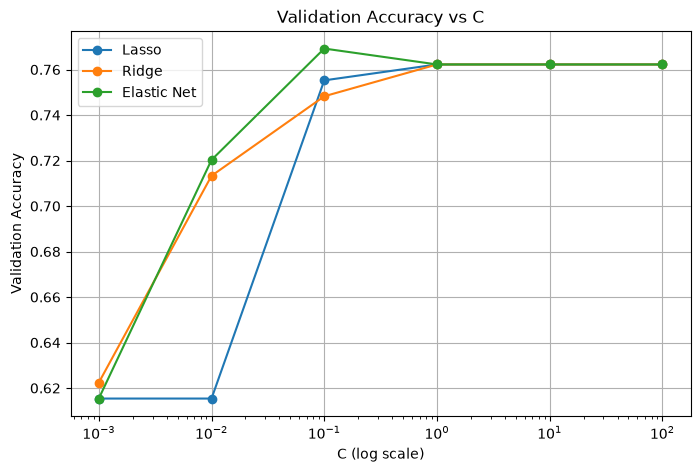

In [9]:
plt.figure(figsize=(8, 5))

plt.semilogx(
    results_df["C"],
    results_df["Lasso_val_acc"],
    marker="o",
    label="Lasso"
)

plt.semilogx(
    results_df["C"],
    results_df["Ridge_val_acc"],
    marker="o",
    label="Ridge"
)

plt.semilogx(
    results_df["C"],
    results_df["ElasticNet_val_acc"],
    marker="o",
    label="Elastic Net"
)

plt.xlabel("C (log scale)")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs C")
plt.legend()
plt.grid(True)
plt.show()

## 8. Non-Zero Coefficients vs C
### This is the sparsity analysis.,As C increases, Lasso generally becomes less sparse.

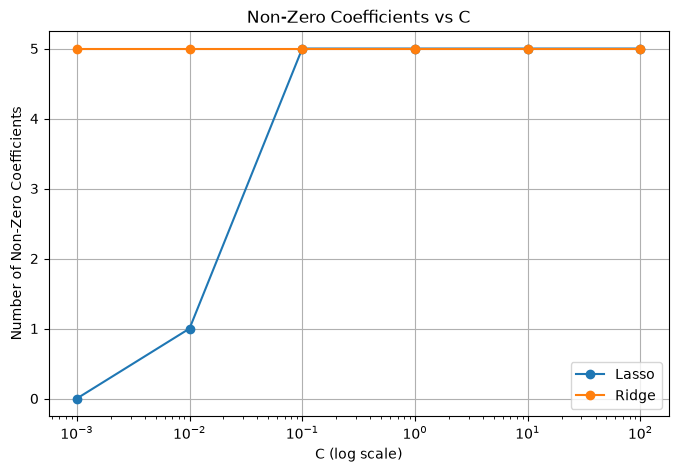

In [10]:
plt.figure(figsize=(8, 5))

plt.semilogx(
    results_df["C"],
    results_df["Lasso_nonzero"],
    marker="o",
    label="Lasso"
)

plt.semilogx(
    results_df["C"],
    results_df["Ridge_nonzero"],
    marker="o",
    label="Ridge"
)

plt.xlabel("C (log scale)")
plt.ylabel("Number of Non-Zero Coefficients")
plt.title("Non-Zero Coefficients vs C")
plt.legend()
plt.grid(True)
plt.show()

## 9. Select Best C Using Validation Accuracy

In [11]:
best_lasso = results_df.loc[results_df["Lasso_val_acc"].idxmax()]
best_ridge = results_df.loc[results_df["Ridge_val_acc"].idxmax()]
best_elastic = results_df.loc[results_df["ElasticNet_val_acc"].idxmax()]

print("Best Lasso:")
display(best_lasso.to_frame().T)

print("Best Ridge:")
display(best_ridge.to_frame().T)

print("Best Elastic Net:")
display(best_elastic.to_frame().T)

Best Lasso:


,C,Lasso_val_acc,Ridge_val_acc,ElasticNet_val_acc,Lasso_nonzero,Ridge_nonzero
3,1.0,0.762238,0.762238,0.762238,5.0,5.0


Best Ridge:


,C,Lasso_val_acc,Ridge_val_acc,ElasticNet_val_acc,Lasso_nonzero,Ridge_nonzero
3,1.0,0.762238,0.762238,0.762238,5.0,5.0


Best Elastic Net:


,C,Lasso_val_acc,Ridge_val_acc,ElasticNet_val_acc,Lasso_nonzero,Ridge_nonzero
2,0.1,0.755245,0.748252,0.769231,5.0,5.0


# Part B — Shrinkage Paths

For each `C`, train Ridge, Lasso and Elastic Net and record every feature coefficient.

This shows how coefficient values change as regularisation changes.

In [12]:
feature_names = list(X_train.columns)

ridge_paths = []
lasso_paths = []
elastic_paths = []

for C in C_values:

    ridge = LogisticRegression(
        penalty="l2",
        C=C,
        solver="lbfgs",
        max_iter=2000,
        random_state=42
    )
    ridge.fit(X_train, y_train)
    ridge_paths.append(ridge.coef_[0])

    lasso = LogisticRegression(
        penalty="l1",
        C=C,
        solver="liblinear",
        max_iter=2000,
        random_state=42
    )
    lasso.fit(X_train, y_train)
    lasso_paths.append(lasso.coef_[0])

    elastic = LogisticRegression(
        penalty="elasticnet",
        C=C,
        l1_ratio=L1_RATIO,
        solver="saga",
        max_iter=3000,
        random_state=42
    )
    elastic.fit(X_train, y_train)
    elastic_paths.append(elastic.coef_[0])

ridge_paths = np.array(ridge_paths)
lasso_paths = np.array(lasso_paths)
elastic_paths = np.array(elastic_paths)

print("Number of model features:", len(feature_names))
print("Ridge path shape:", ridge_paths.shape)
print("Lasso path shape:", lasso_paths.shape)
print("Elastic Net path shape:", elastic_paths.shape)

Number of model features: 5
Ridge path shape: (6, 5)
Lasso path shape: (6, 5)
Elastic Net path shape: (6, 5)


C:\Users\dhruv\OneDrive\KLH Univeristy\4th semester (Trimester Format KLH)\25SC2107E Machine Learning\Placement Prediction System (OS-SEC-2(2026-27))\.MLvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\dhruv\OneDrive\KLH Univeristy\4th semester (Trimester Format KLH)\25SC2107E Machine Learning\Placement Prediction System (OS-SEC-2(2026-27))\.MLvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead

## 10. Ridge Shrinkage Path

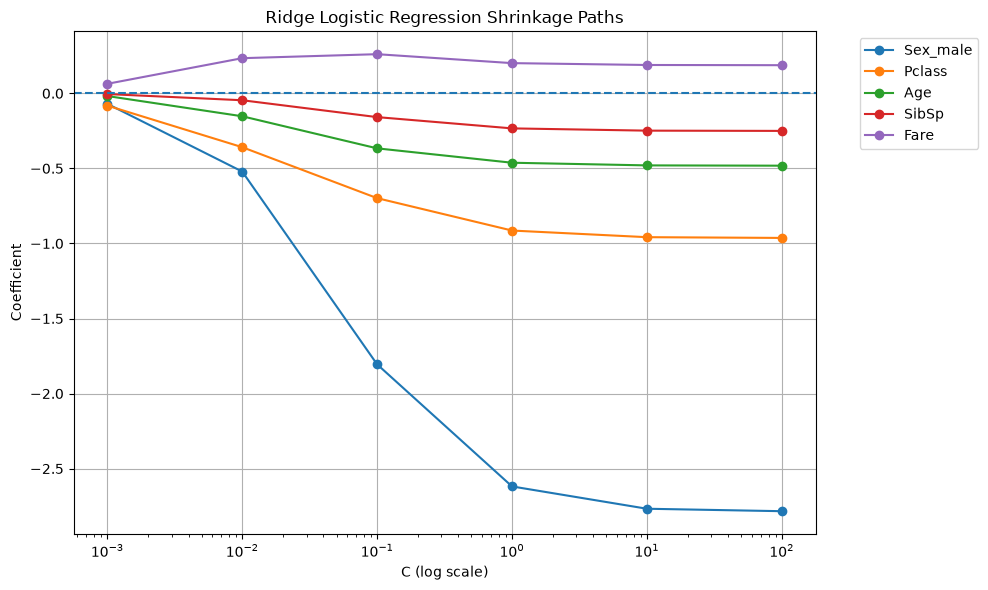

In [13]:
plt.figure(figsize=(10, 6))

for j, feature in enumerate(feature_names):
    plt.semilogx(
        C_values,
        ridge_paths[:, j],
        marker="o",
        label=feature
    )

plt.axhline(0, linestyle="--")
plt.xlabel("C (log scale)")
plt.ylabel("Coefficient")
plt.title("Ridge Logistic Regression Shrinkage Paths")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

## 11. Lasso Shrinkage Path

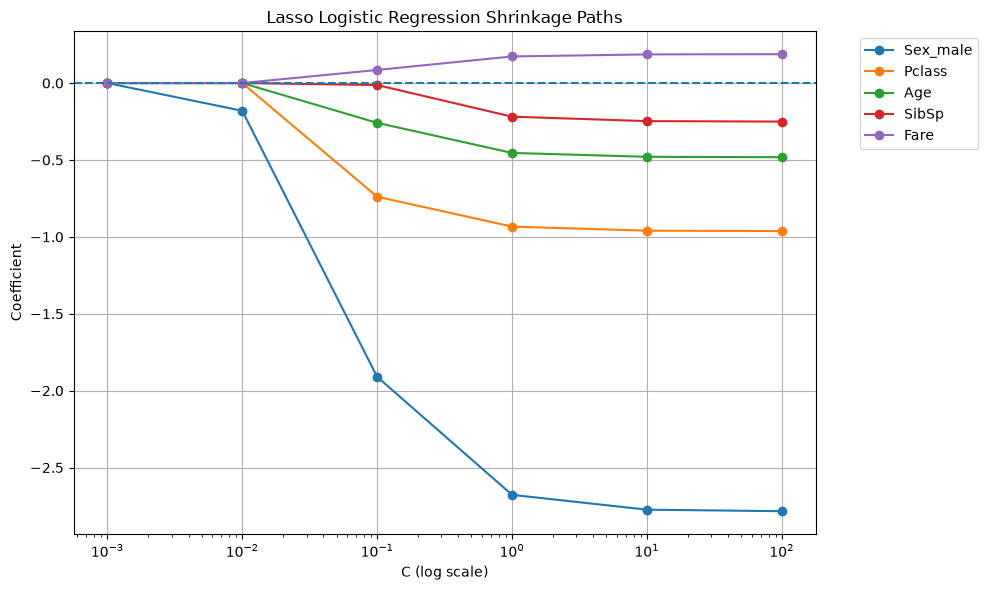

In [14]:
plt.figure(figsize=(10, 6))

for j, feature in enumerate(feature_names):
    plt.semilogx(
        C_values,
        lasso_paths[:, j],
        marker="o",
        label=feature
    )

plt.axhline(0, linestyle="--")
plt.xlabel("C (log scale)")
plt.ylabel("Coefficient")
plt.title("Lasso Logistic Regression Shrinkage Paths")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

## 12. Elastic Net Shrinkage Path

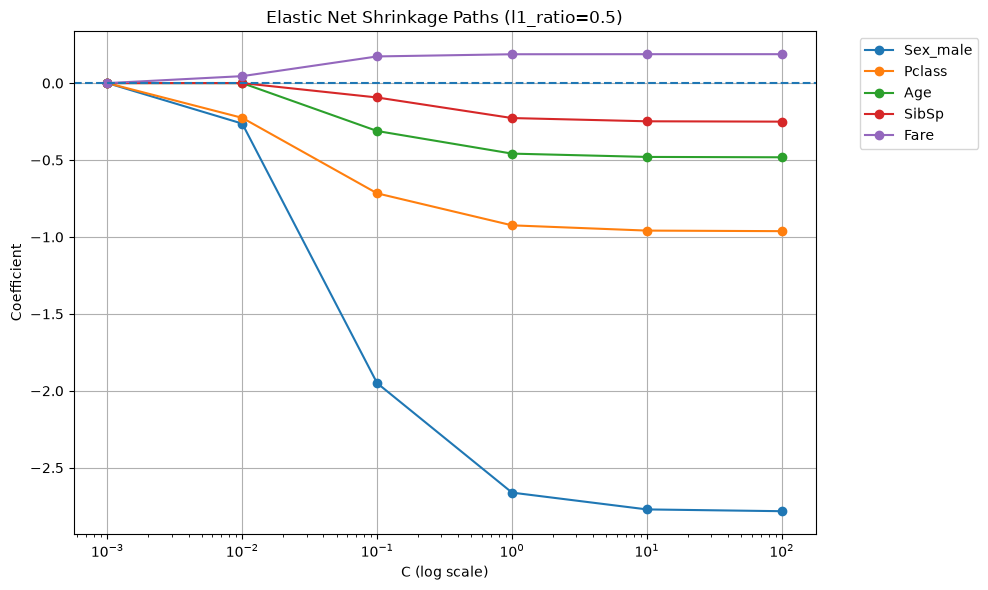

In [15]:
plt.figure(figsize=(10, 6))

for j, feature in enumerate(feature_names):
    plt.semilogx(
        C_values,
        elastic_paths[:, j],
        marker="o",
        label=feature
    )

plt.axhline(0, linestyle="--")
plt.xlabel("C (log scale)")
plt.ylabel("Coefficient")
plt.title(f"Elastic Net Shrinkage Paths (l1_ratio={L1_RATIO})")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

## 13. Coefficient Comparison at Best C

In [16]:
best_C_lasso = float(best_lasso["C"])
best_C_ridge = float(best_ridge["C"])
best_C_elastic = float(best_elastic["C"])

lasso_best = LogisticRegression(
    penalty="l1",
    C=best_C_lasso,
    solver="liblinear",
    max_iter=2000,
    random_state=42
)
lasso_best.fit(X_train, y_train)

ridge_best = LogisticRegression(
    penalty="l2",
    C=best_C_ridge,
    solver="lbfgs",
    max_iter=2000,
    random_state=42
)
ridge_best.fit(X_train, y_train)

elastic_best = LogisticRegression(
    penalty="elasticnet",
    C=best_C_elastic,
    l1_ratio=L1_RATIO,
    solver="saga",
    max_iter=3000,
    random_state=42
)
elastic_best.fit(X_train, y_train)

coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Ridge": ridge_best.coef_[0],
    "Lasso": lasso_best.coef_[0],
    "ElasticNet": elastic_best.coef_[0]
})

display(coefficient_table)

C:\Users\dhruv\OneDrive\KLH Univeristy\4th semester (Trimester Format KLH)\25SC2107E Machine Learning\Placement Prediction System (OS-SEC-2(2026-27))\.MLvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\dhruv\OneDrive\KLH Univeristy\4th semester (Trimester Format KLH)\25SC2107E Machine Learning\Placement Prediction System (OS-SEC-2(2026-27))\.MLvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\dhruv\OneDrive\KLH Univeristy\4th semester

,Feature,Ridge,Lasso,ElasticNet
0,Sex_male,-2.618552,-2.677085,-1.950170
1,Pclass,-0.914013,-0.933217,-0.716526
2,Age,-0.462263,-0.454251,-0.311413
3,SibSp,-0.233428,-0.218576,-0.093537
4,Fare,0.201283,0.172931,0.173283


## 14. Final Test Evaluation

The 20% test set was not used during `C` selection. Now evaluate the selected model once on `X_test`.

The model with the highest validation accuracy is selected.

In [17]:
best_candidates = {
    "Lasso": (best_C_lasso, float(best_lasso["Lasso_val_acc"])),
    "Ridge": (best_C_ridge, float(best_ridge["Ridge_val_acc"])),
    "ElasticNet": (best_C_elastic, float(best_elastic["ElasticNet_val_acc"]))
}

best_method = max(
    best_candidates,
    key=lambda name: best_candidates[name][1]
)

if best_method == "Lasso":
    final_model = lasso_best
elif best_method == "Ridge":
    final_model = ridge_best
else:
    final_model = elastic_best

y_test_pred = final_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Selected model:", best_method)
print("Selected C:", best_candidates[best_method][0])
print("Validation accuracy:", best_candidates[best_method][1])
print("Final test accuracy:", test_accuracy)

Selected model: ElasticNet
Selected C: 0.1
Validation accuracy: 0.7692307692307693
Final test accuracy: 0.7932960893854749


# Practical Conclusion

### Part A — Regularisation comparison
- Implement `compare_regularisation()`.
- Compare Ridge, Lasso and Elastic Net across different `C` values.
- Compare validation accuracy.
- Compare non-zero coefficient counts.
- Select the best model and `C` using validation performance.

### Part B — Shrinkage paths
- Plot Ridge coefficient paths.
- Plot Lasso coefficient paths.
- Plot Elastic Net coefficient paths.
- Explain how stronger regularisation shrinks coefficients.
- Explain why Lasso can produce zero coefficients.

### Final evaluation
Use the untouched 20% test set only after model and `C` selection.